Task 3: Car Price Prediction with Machine Learning

Name: Karan Dattatray Tormal

College: Vivekanand College

Task: Car Price Prediction with Machine Learning (Predicting Used Car Selling Price using Regression Models)

## 1. Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")
%matplotlib inline

## 2. Load Dataset

In [2]:
df = pd.read_csv("Car_details_v3.csv")
print("Shape:", df.shape)
df.head()

Shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [4]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

## 3. Data Cleaning

We will:
- Drop rows with missing values (small % of dataset)
- Remove duplicate rows
- Clean units out of numeric-looking columns (`mileage`, `engine`, `max_power`)
- Standardise categorical text (lowercasing/stripping)

In [5]:
df_clean = df.copy()

# Remove duplicates
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - df_clean.shape[0]} duplicate rows")

# Drop rows with nulls (mileage, engine, max_power, torque, seats)
before = df_clean.shape[0]
df_clean = df_clean.dropna()
print(f"Removed {before - df_clean.shape[0]} rows with null values")

df_clean.shape

Removed 1202 duplicate rows
Removed 209 rows with null values


(6717, 13)

In [6]:
# Strip units from numeric-looking text columns
df_clean['mileage'] = df_clean['mileage'].str.split(' ').str[0].astype(float)
df_clean['engine'] = df_clean['engine'].str.split(' ').str[0].astype(float)
df_clean['max_power'] = df_clean['max_power'].str.split(' ').str[0].replace('', np.nan).astype(float)

# Standardise categorical text
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    df_clean[col] = df_clean[col].str.strip().str.title()

df_clean = df_clean.dropna()  # drop any new NaNs created by unit-stripping
df_clean.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


## 4. Feature Engineering

- `car_age` = current year - manufacture year
- `brand` = first word of the `name` column
- Drop `name` (too high cardinality) and `torque` (complex string field, not used)

In [7]:
CURRENT_YEAR = 2024
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']
df_clean['brand'] = df_clean['name'].str.split(' ').str[0]

df_clean = df_clean.drop(columns=['name', 'torque', 'year'])
df_clean.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,car_age,brand
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,10,Maruti
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,10,Skoda
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,18,Honda
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,14,Hyundai
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,17,Maruti


In [8]:
print("Number of unique brands:", df_clean['brand'].nunique())
df_clean['brand'].value_counts().head(15)

Number of unique brands: 31


brand
Maruti           2089
Hyundai          1214
Mahindra          709
Tata              633
Honda             361
Ford              353
Toyota            324
Chevrolet         216
Renault           206
Volkswagen        173
Nissan             73
Skoda              69
Datsun             57
Mercedes-Benz      46
BMW                45
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of Selling Price

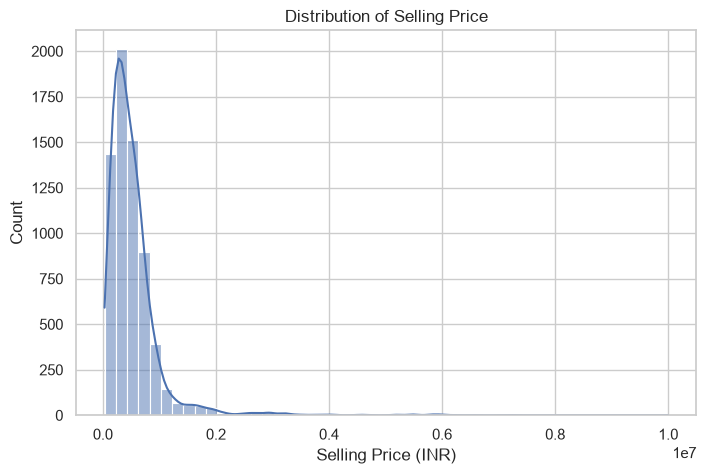

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['selling_price'], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (INR)")
plt.show()

**Observation:** The selling price distribution is heavily right-skewed — most cars sell in the lower price range, with a long tail of expensive/luxury cars.

### 5.2 Selling Price vs Fuel Type

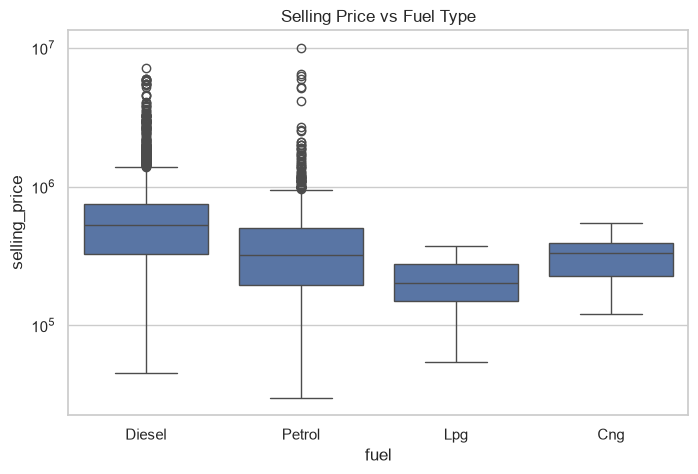

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='fuel', y='selling_price')
plt.title("Selling Price vs Fuel Type")
plt.yscale('log')
plt.show()

**Observation:** Diesel cars tend to have a higher median selling price compared to Petrol and CNG cars.

### 5.3 Selling Price vs Car Age

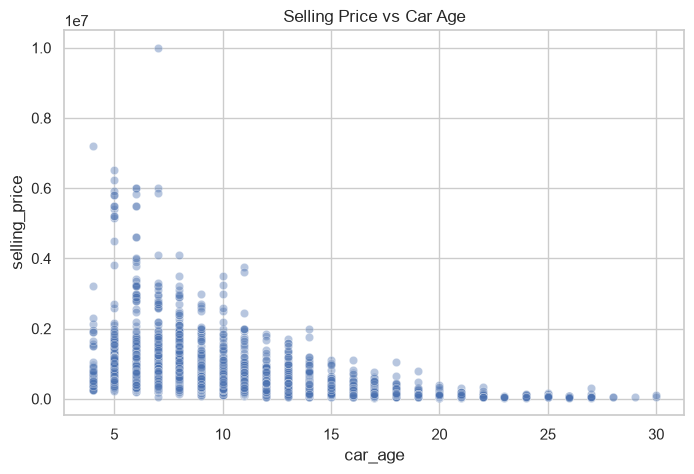

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x='car_age', y='selling_price', alpha=0.4)
plt.title("Selling Price vs Car Age")
plt.show()

**Observation:** As expected, selling price generally decreases as car age increases, though there is significant scatter due to brand/model/condition differences.

## 6. Encode Categorical Variables

In [12]:
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.shape

(6717, 47)

## 7. Feature Correlation Heatmap

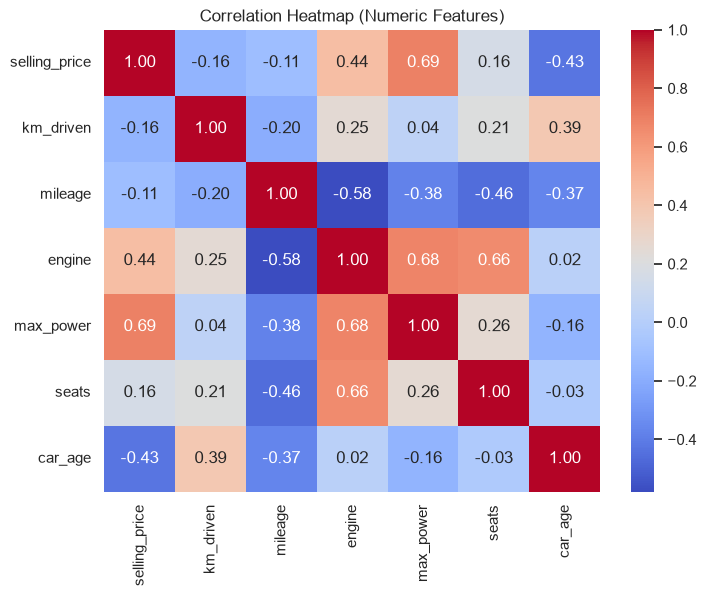

In [13]:
plt.figure(figsize=(8,6))
numeric_cols = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

**Observation:** `max_power` and `engine` show a strong positive correlation with `selling_price`, while `car_age` and `km_driven` are negatively correlated with it.

## 8. Train/Test Split

In [14]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (5373, 46) Test shape: (1344, 46)


## 9. Model Training

We train two regression models: **Linear Regression** (baseline) and **Random Forest Regressor**.

In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [16]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

## 10. Model Evaluation

In [17]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R2   : {r2:.4f}")
    print()
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Random Forest Regressor", y_test, rf_preds))

results_df = pd.DataFrame(results)
results_df

Linear Regression
  MAE  : 139,224.46
  RMSE : 224,710.83
  R2   : 0.7699

Random Forest Regressor
  MAE  : 73,854.75
  RMSE : 124,847.54
  R2   : 0.9290



,Model,MAE,RMSE,R2
0,Linear Regression,139224.458063,224710.827876,0.769882
1,Random Forest Regressor,73854.746287,124847.543146,0.928967


**Best model:** The Random Forest Regressor is expected to outperform Linear Regression here because car price is influenced by non-linear interactions between features (e.g., brand + age + engine size together), which tree-based models capture better than a linear model.

## 11. Feature Importance (Random Forest)

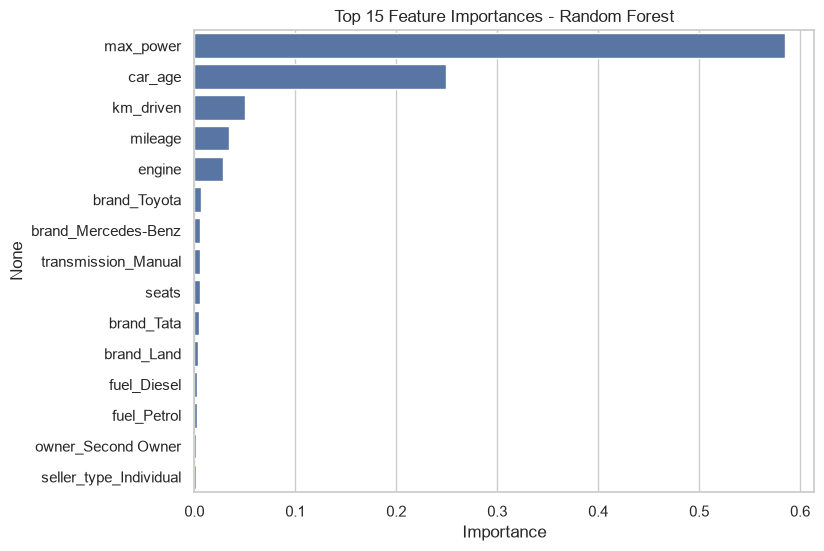

In [18]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

**Observation:** `max_power`, `car_age`, and `engine` are typically the most influential features in predicting a used car's selling price.

## 12. Conclusion

- We cleaned and engineered features from the raw CarDekho dataset (car age, brand extraction, unit stripping).
- We trained and compared two regression models: Linear Regression and Random Forest Regressor.
- The Random Forest model achieved better performance (lower MAE/RMSE, higher R²), showing it captures non-linear relationships in car pricing better.
- The most important predictors of selling price were engine power, car age, and engine size.

**Next steps (optional improvements):** try Gradient Boosting / XGBoost, hyperparameter tuning (GridSearchCV), and log-transforming the skewed target variable.